# Truthfulness EDA

§1–§6 lean EDA. §7 LR on a multi-source feature stack with `|coef|` importance.


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 2. Load


In [2]:
DATA_PATH = "/Users/thanos.lyras/Desktop/Satalia-projects/internal/data science challenge with agents/data.csv"
df = pd.read_csv(DATA_PATH)
print(f"{len(df):,} rows × {df.shape[1]} cols")
df.head()


9,627 rows × 8 cols


,Label,statement,subjects,speaker_name,speaker_job,speaker_state,speaker_affiliation,statement_context
0,half-true,"Before we even passed health care, 4 millions ...",families$health-care,barack-obama,President,Illinois,democrat,an interview on The Daily Show.
1,true,The mayor said 'if you happen to be in this co...,immigration,mitt-romney,Former governor,Massachusetts,republican,"a debate in St. Petersburg, Fla."
2,mostly-true,Sarah Palin was repeating Abraham Lincoln's wo...,religion,sarah-palin,NaN,Alaska,republican,"Fairbanks, Alaska"
3,mostly-true,NASCAR fans are twice as likely as non fans to...,military,steve-phelps,"Chief Marketing Officer, NASCAR",NaN,none,NaN
4,barely-true,"In Florida, 300,000 people are going to lose t...",health-care,marco-rubio,U.S. Senator,Florida,republican,an interview on The O'Reilly Factor.


## 3. Basic info


In [3]:
print("Columns:", list(df.columns))
print()
df.info()


Columns: ['Label', 'statement', 'subjects', 'speaker_name', 'speaker_job', 'speaker_state', 'speaker_affiliation', 'statement_context']

<class 'pandas.DataFrame'>
RangeIndex: 9627 entries, 0 to 9626
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Label                9627 non-null   str  
 1   statement            9627 non-null   str  
 2   subjects             9627 non-null   str  
 3   speaker_name         9627 non-null   str  
 4   speaker_job          6957 non-null   str  
 5   speaker_state        7559 non-null   str  
 6   speaker_affiliation  9627 non-null   str  
 7   statement_context    9531 non-null   str  
dtypes: str(8)
memory usage: 2.5 MB


## 4. Missing values


                   missing   pct
speaker_job           2670  27.7
speaker_state         2068  21.5
statement_context       96   1.0


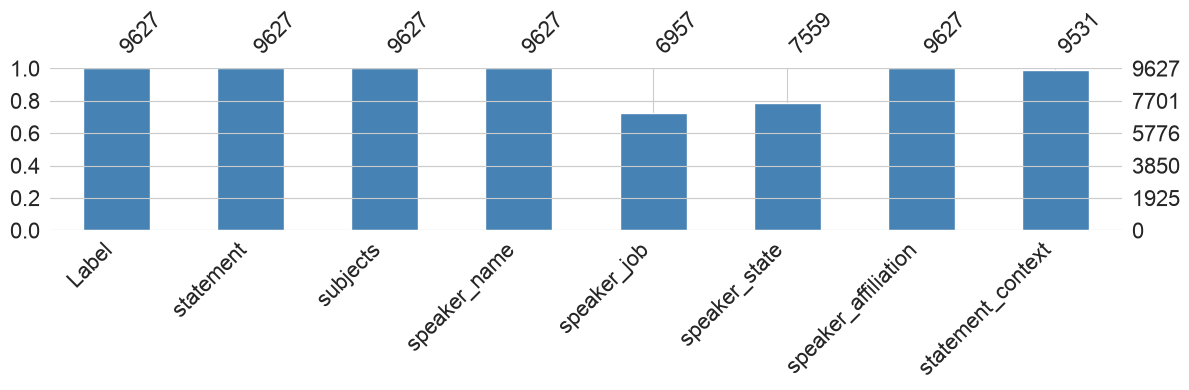

In [4]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({"missing": missing, "pct": (missing / len(df) * 100).round(1)})
print(missing_df[missing_df["missing"] > 0].sort_values("pct", ascending=False))

fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(df, ax=ax, color="steelblue")
plt.tight_layout(); plt.show()


## 5. Label mapping (6-way → binary)

`true` / `mostly-true` / `half-true` → **1**  ·  `barely-true` / `false` / `extremely-false` → **0**.


In [5]:
LABEL_MAP = {
    "true": 1, "mostly-true": 1, "half-true": 1,
    "barely-true": 0, "false": 0, "extremely-false": 0,
}
df["binary_label"] = df["Label"].map(LABEL_MAP)
assert df["binary_label"].notna().all()

print(df["Label"].value_counts())
print()
print(df["binary_label"].value_counts(), f"   ratio TRUE/FALSE = {df['binary_label'].mean() / (1 - df['binary_label'].mean()):.2f}")


Label
half-true          1978
false              1869
mostly-true        1851
barely-true        1587
true               1538
extremely-false     804
Name: count, dtype: int64

binary_label
1    5367
0    4260
Name: count, dtype: int64    ratio TRUE/FALSE = 1.26


## 6. Target distribution


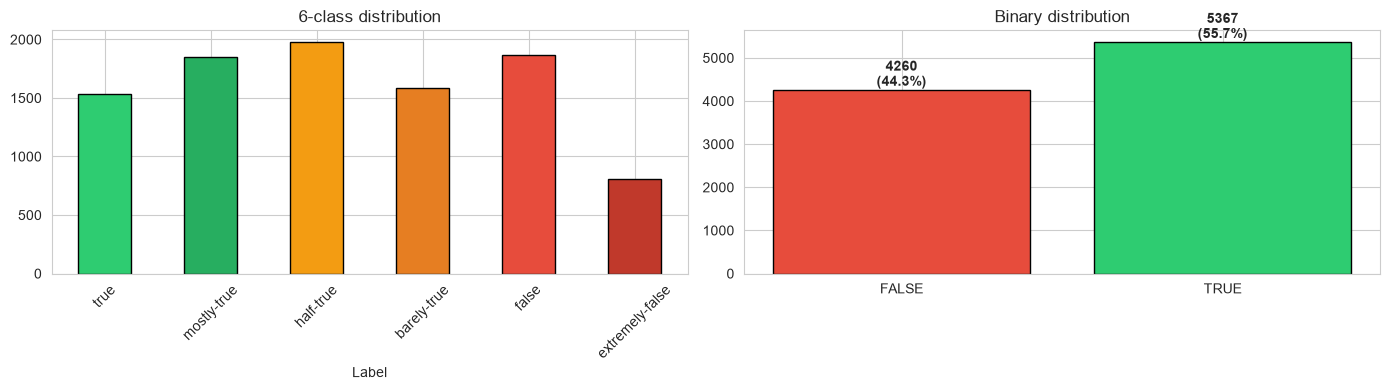

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_order = ["true", "mostly-true", "half-true", "barely-true", "false", "extremely-false"]
colors_6 = ["#2ecc71", "#27ae60", "#f39c12", "#e67e22", "#e74c3c", "#c0392b"]
df["Label"].value_counts().reindex(label_order).plot(
    kind="bar", ax=axes[0], color=colors_6, edgecolor="black"
)
axes[0].set_title("6-class distribution"); axes[0].tick_params(axis="x", rotation=45)

binary_counts = df["binary_label"].value_counts().sort_index()
axes[1].bar(["FALSE", "TRUE"], binary_counts, color=["#e74c3c", "#2ecc71"], edgecolor="black")
for i, c in enumerate(binary_counts):
    axes[1].text(i, c, f"{c}\n({c/len(df)*100:.1f}%)", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Binary distribution")

plt.tight_layout(); plt.show()


## 7. Modeling — LR on multi-source feature stack

Features: TF-IDF(statement/subjects/context) + numeric length + target-encoded speakers + one-hot state/party. Use `|coef|` (after MaxAbsScaler) as importance.

⚠️ `speaker_encoded` is target-encoded on the full dataset → mild leakage; documented, kept.


### 7.1 Feature engineering


In [7]:
import re
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

df_m = df.copy()
for col in ["statement", "subjects", "statement_context"]:
    df_m[col] = df_m[col].fillna("").str.lower().apply(lambda t: re.sub(r"[^\w\s]", " ", t))

# TF-IDF
tfidf_statement = TfidfVectorizer(max_features=2000, stop_words="english", ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_subjects  = TfidfVectorizer(max_features=200, token_pattern=r"[^$\s]+")
tfidf_context   = TfidfVectorizer(max_features=200, stop_words="english")
X_statement = tfidf_statement.fit_transform(df_m["statement"])
X_subjects  = tfidf_subjects.fit_transform(df_m["subjects"])
X_context   = tfidf_context.fit_transform(df_m["statement_context"])

# Numeric (length)
NUMERIC_COLS = ["statement_char_len", "statement_word_count"]
df_m["statement_char_len"]   = df["statement"].str.len()
df_m["statement_word_count"] = df["statement"].str.split().str.len()
X_numeric = df_m[NUMERIC_COLS].to_numpy()

# Target-encoded speakers (leaky — see §7 header)
mean_label = df_m["binary_label"].mean()
df_m["speaker_encoded"]     = df_m["speaker_name"].map(df_m.groupby("speaker_name")["binary_label"].mean()).fillna(mean_label)
df_m["speaker_job_encoded"] = df_m["speaker_job"].fillna("__missing__").map(
    df_m.fillna({"speaker_job": "__missing__"}).groupby("speaker_job")["binary_label"].mean()
).fillna(mean_label)
X_speakers = df_m[["speaker_encoded", "speaker_job_encoded"]].to_numpy()

# One-hot state + party
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_cat = ohe.fit_transform(df_m[["speaker_state", "speaker_affiliation"]].fillna("__missing__"))

# Stack
X = hstack([X_statement, X_subjects, X_context, csr_matrix(X_numeric), csr_matrix(X_speakers), X_cat]).tocsr()
y = df_m["binary_label"].to_numpy()

print(f"X: {X.shape}")
print(f"  tfidf(statement/subjects/context) = {X_statement.shape[1]}/{X_subjects.shape[1]}/{X_context.shape[1]}")
print(f"  numeric={X_numeric.shape[1]}  speakers={X_speakers.shape[1]}  one-hot={X_cat.shape[1]}")


X: (9627, 2488)
  tfidf(statement/subjects/context) = 2000/182/200
  numeric=2  speakers=2  one-hot=102


### 7.2 Split, scale, fit


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
scaler = MaxAbsScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, solver="liblinear", class_weight="balanced", random_state=42)
model.fit(X_train, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `

### 7.3 Test-set metrics


acc = 0.738   f1 = 0.762
              precision    recall  f1-score   support

       FALSE       0.70      0.72      0.71       852
        TRUE       0.77      0.75      0.76      1074

    accuracy                           0.74      1926
   macro avg       0.73      0.74      0.74      1926
weighted avg       0.74      0.74      0.74      1926



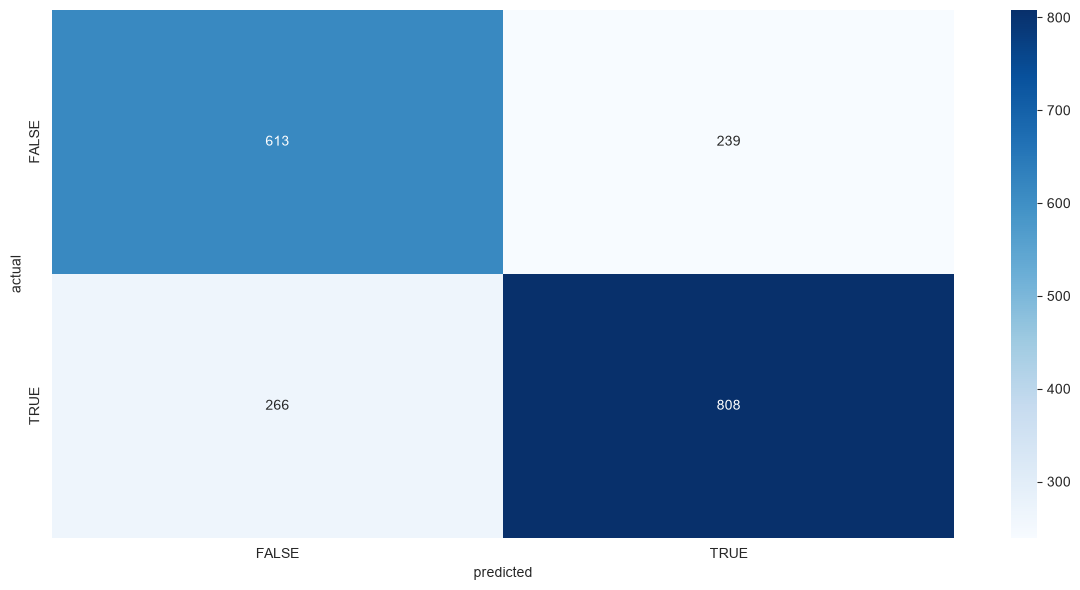

In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(f"acc = {accuracy_score(y_test, y_pred):.3f}   f1 = {f1_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=["FALSE", "TRUE"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FALSE", "TRUE"], yticklabels=["FALSE", "TRUE"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.tight_layout(); plt.show()


### 7.4 Top-10 feature importance (|coef|)


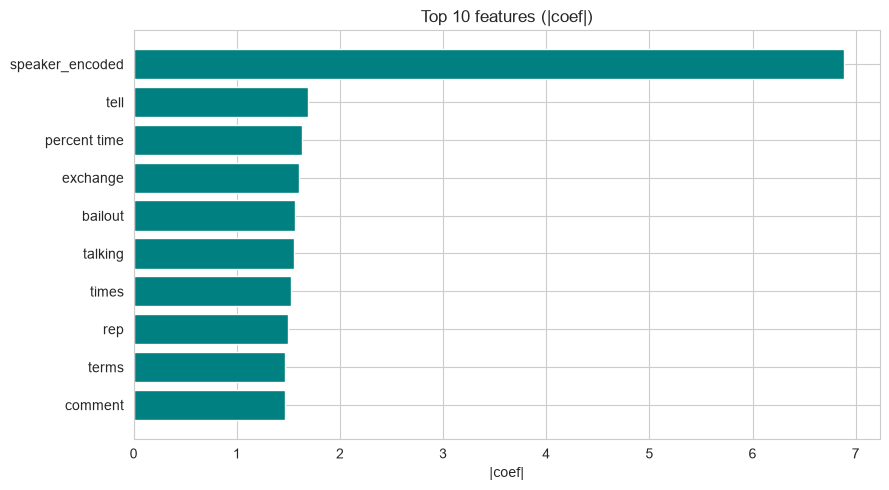

In [10]:
all_names = np.concatenate([
    tfidf_statement.get_feature_names_out(),
    tfidf_subjects.get_feature_names_out(),
    tfidf_context.get_feature_names_out(),
    np.array(NUMERIC_COLS),
    np.array(["speaker_encoded", "speaker_job_encoded"]),
    ohe.get_feature_names_out(),
])
imp = np.abs(model.coef_[0])
top = np.argsort(imp)[-10:]

plt.figure(figsize=(9, 5))
plt.barh(range(len(top)), imp[top], color="teal")
plt.yticks(range(len(top)), all_names[top])
plt.title("Top 10 features (|coef|)"); plt.xlabel("|coef|")
plt.tight_layout(); plt.show()


### 7.5 Importance per source


                         n  sum|coef|  mean|coef|
speakers(target-enc)     2      7.093       3.546
numeric(length)          2      1.140       0.570
statement(TF-IDF)     2000    779.615       0.390
context(TF-IDF)        200     71.583       0.358
subjects(TF-IDF)       182     51.105       0.281
state+party(1-hot)     102     15.844       0.155


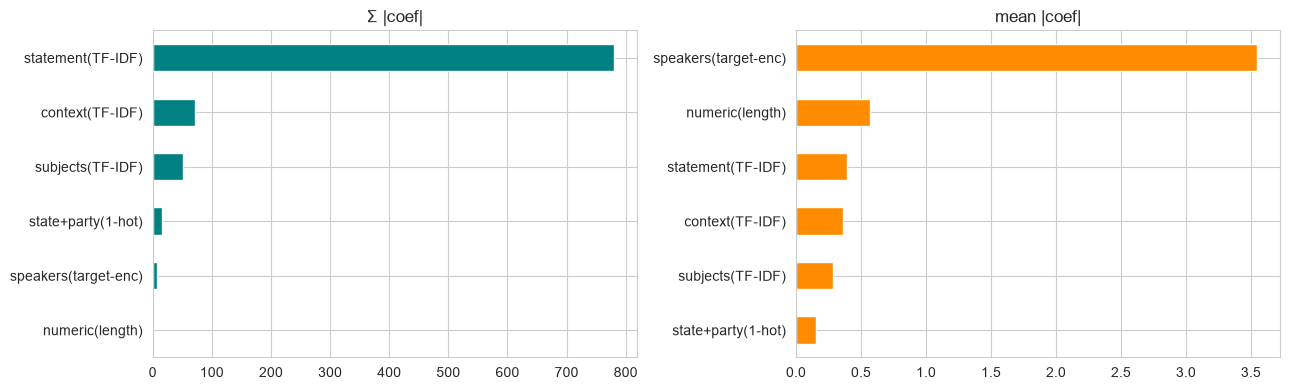

In [11]:
sizes = [X_statement.shape[1], X_subjects.shape[1], X_context.shape[1],
         len(NUMERIC_COLS), 2, X_cat.shape[1]]
names = ["statement(TF-IDF)", "subjects(TF-IDF)", "context(TF-IDF)",
         "numeric(length)", "speakers(target-enc)", "state+party(1-hot)"]
slices = np.split(imp, np.cumsum(sizes)[:-1])

summary = pd.DataFrame({
    "n": sizes,
    "sum|coef|":  [s.sum() for s in slices],
    "mean|coef|": [s.mean() for s in slices],
}, index=names).sort_values("mean|coef|", ascending=False)
print(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary["sum|coef|"].sort_values().plot.barh(ax=axes[0], color="teal").set_title("Σ |coef|")
summary["mean|coef|"].sort_values().plot.barh(ax=axes[1], color="darkorange").set_title("mean |coef|")
plt.tight_layout(); plt.show()


## 8. Findings

- **Classes are roughly balanced** (56% TRUE / 44% FALSE). Just stratify the split — no class weights needed.
- **Some columns are often empty** (`speaker_job` 28%, `speaker_state` 21%). When building the prompt, skip empty fields instead of writing blank lines.
- **Speaker matters the most per feature.** Who said something is the strongest single signal of truthfulness, so the LLM must always see the speaker name.
- **Statement text matters the most overall.** Taken together, the words of the statement carry more total signal than any other column. Always include the full statement in the prompt.
- **Small caveat:** our speaker-importance number is slightly inflated because we computed it on the whole dataset (the model gets a tiny peek at each row's own label). For the real evaluation later, recompute on the training split only.
